In [1]:
import sys
import os
import pandas as pd
import numpy as np
from sklearn import set_config
set_config(transform_output="pandas")

sys.path.append(os.path.abspath('../src'))
from sklearn.model_selection import train_test_split
from DataLoader import DataLoader
from DataSplitter import DataSplitter
from Transformer import Transformer
from InteractionsTransformer import InteractionsTransformer
from PreProcessor import PreProcessor
from ModelCollection import ModelCollection
from PipelineBuilder import PipelineBuilder
from CrossValidation import CrossValidation
from EnsembleBuilder import EnsembleBuilder

In [2]:
config_path = "../src/config.jsonc"
path_train, path_test = "../data/train.csv", "../data/test.csv"
data_loader = DataLoader(path_train, path_test)
train, test = data_loader.load()

In [3]:
test

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal
1455,2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml
1456,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml
1457,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal


In [4]:
# Removing outliers
outliers = train[(train["GrLivArea"] > 4000) & (train["SalePrice"] < 300000)].index
train = train.drop(outliers)

In [5]:
train['SalePrice'] = np.log1p(train['SalePrice'])
data_splitter = DataSplitter("SalePrice", test_size=0.2)
X_train, X_test, y_train, y_test = data_splitter.split(train)
X_train.shape, X_test.shape, y_train.shape, y_test.shape, X_train.shape[0]/(X_train.shape[0]+X_test.shape[0])

((1166, 80), (292, 80), (1166,), (292,), 0.7997256515775034)

In [6]:
# ML pipeline
pipeline_builder = PipelineBuilder(config_path=config_path, df=train)

$\textbf{OLS}$

In [7]:
## OLS fit on X_train, y_train:

pipeline = pipeline_builder.build(model_name='OLS')
pipeline.fit(X_train, y_train)
preds = pd.Series(pipeline.predict(X_test), index=y_test.index)

results = pd.DataFrame({'y_test': y_test.values, 'pred': preds.values.astype(int)})
results['Diff%'] = 100 * abs((results['y_test']-results['pred']) / results['y_test'])
print(results.describe())
feature_names = pipeline.named_steps["preprocess"].get_feature_names_out()

           y_test        pred       Diff%
count  292.000000  292.000000  292.000000
mean    12.026625   11.510274    4.351461
std      0.411285    0.533964    2.571101
min     10.471978   10.000000    0.038105
25%     11.770477   11.000000    1.885821
50%     12.026017   12.000000    4.514839
75%     12.332681   12.000000    6.530031
max     13.021329   13.000000   14.182950


In [8]:
## Cross-validation score

n_folds = 5
cv = CrossValidation(n_folds, pipeline)
X, y = train.drop(columns=['SalePrice']), train['SalePrice']
score_stats = cv.evaluate(X,y)
print(score_stats)

{'mean_rmse': np.float64(0.12188367125771049), 'std_rmse': np.float64(0.00900235447287807)}


In [9]:
## Hyper-parameter tunning
param_grid = {
    "model__fit_intercept": [False, True]
}
search_ols = cv.hyper_param_tune(X, y, param_grid)

In [10]:
## Predicting on test set 
X_train, y_train = train.drop(columns=['SalePrice']), train['SalePrice']
pipeline.fit(X_train, y_train)
preds = np.expm1(pipeline.predict(test))
submission = pd.DataFrame({"Id": test["Id"], "SalePrice": preds})
submission.to_csv("../data/submission_ols.csv", index=False)

$\textbf{Linear Regression (Regularized Models) - Ridge and Lasso}$

$Ridge:$

In [11]:
pipeline = pipeline_builder.build(model_name='Ridge')
pipeline.fit(X_train, y_train)
preds = pd.Series(pipeline.predict(X_test), index=y_test.index)

results = pd.DataFrame({'y_test': y_test.values, 'pred': preds.values.astype(int)})
results['Diff%'] = 100 * abs((results['y_test']-results['pred']) / results['y_test'])
print(results.describe())

           y_test        pred       Diff%
count  292.000000  292.000000  292.000000
mean    12.026625   11.520548    4.259201
std      0.411285    0.527188    2.476708
min     10.471978   10.000000    0.038105
25%     11.770477   11.000000    1.840515
50%     12.026017   12.000000    4.481177
75%     12.332681   12.000000    6.498886
max     13.021329   13.000000    9.137901


In [12]:
## Cross-validation score
n_folds = 5
cv = CrossValidation(n_folds, pipeline)
X, y = train.drop(columns=['SalePrice']), train['SalePrice']
score_stats = cv.evaluate(X,y)
print(score_stats)

{'mean_rmse': np.float64(0.1143932144745488), 'std_rmse': np.float64(0.006824474449026753)}


In [13]:
## Hyper-parameter tunning
param_grid = {
    "model__alpha": [0.1, 0.3, 0.5, 0.7, 0.9, 1.1, 1.5, 2.0, 3, 5, 10, 20, 30, 40, 50, 100]
}
search_ridge = cv.hyper_param_tune(X, y, param_grid)
results = pd.DataFrame(search_ridge.cv_results_)
results = results.sort_values("mean_test_score", ascending=False)
results[['param_model__alpha', 'mean_test_score', 'std_test_score']]

,param_model__alpha,mean_test_score,std_test_score
11,20.0,-0.110625,0.007550
10,10.0,-0.110681,0.007226
12,30.0,-0.110847,0.007719
13,40.0,-0.111140,0.007820
9,5.0,-0.111230,0.006929
14,50.0,-0.111456,0.007886
8,3.0,-0.111959,0.006781
7,2.0,-0.112734,0.006730
15,100.0,-0.113032,0.008022
6,1.5,-0.113378,0.006739


In [14]:
coefs_values = search_ridge.best_estimator_.named_steps["model"].coef_
feature_names = search_ridge.best_estimator_.named_steps["interactions"].feature_names_out_
coefs_df = pd.DataFrame({'Feature': feature_names, "Coefficient": coefs_values})
coefs_df = coefs_df.sort_values(by='Coefficient', key=abs, ascending=False)
coefs_df.head(50)
coefs_df[coefs_df["Feature"] == "QualTotalSF"]

,Feature,Coefficient


In [15]:
preds = np.expm1(search_ridge.best_estimator_.predict(test))
submission = pd.DataFrame({"Id": test["Id"], "SalePrice": preds})
submission.to_csv("../data/submission_ridge.csv", index=False)

$Lasso:$

In [16]:
pipeline = pipeline_builder.build(model_name='Lasso')
pipeline.fit(X_train, y_train)
preds = pd.Series(pipeline.predict(X_test), index=y_test.index)

results = pd.DataFrame({'y_test': y_test.values, 'pred': preds.values.astype(int)})
results['Diff%'] = 100 * abs((results['y_test']-results['pred']) / results['y_test'])
print(results.describe())

           y_test   pred       Diff%
count  292.000000  292.0  292.000000
mean    12.026625   12.0    2.707388
std      0.411285    0.0    2.163577
min     10.471978   12.0    0.038105
25%     11.770477   12.0    1.182001
50%     12.026017   12.0    2.110711
75%     12.332681   12.0    3.707833
max     13.021329   12.0   14.591530


In [17]:
## Cross-validation score
n_folds = 5
cv = CrossValidation(n_folds, pipeline)
X, y = train.drop(columns=['SalePrice']), train['SalePrice']
score_stats = cv.evaluate(X,y)
print(score_stats)

{'mean_rmse': np.float64(0.399284908349551), 'std_rmse': np.float64(0.016812295456188092)}


In [18]:
## Hyper-parameter tunning
param_grid = {
    "model__alpha": [0.1, 0.3, 0.5, 0.7, 0.9, 1.1, 1.5, 2.0, 3, 5, 10, 20, 30, 40, 50, 100]
}
search_lasso = cv.hyper_param_tune(X, y, param_grid)
results = pd.DataFrame(search_lasso.cv_results_)
results = results.sort_values("mean_test_score", ascending=False)
results[['param_model__alpha', 'mean_test_score', 'std_test_score']]

,param_model__alpha,mean_test_score,std_test_score
0,0.1,-0.198730,0.008363
1,0.3,-0.371428,0.020116
2,0.5,-0.399285,0.016812
3,0.7,-0.399285,0.016812
4,0.9,-0.399285,0.016812
5,1.1,-0.399285,0.016812
6,1.5,-0.399285,0.016812
7,2.0,-0.399285,0.016812
8,3.0,-0.399285,0.016812
9,5.0,-0.399285,0.016812


In [19]:
coefs_values = search_lasso.best_estimator_.named_steps["model"].coef_
feature_names = search_lasso.best_estimator_.named_steps["interactions"].feature_names_out_
coefs_df = pd.DataFrame({'Feature': feature_names, "Coefficient": coefs_values})
coefs_df = coefs_df.sort_values(by='Coefficient', key=abs, ascending=False)
coefs_df.head(10)

,Feature,Coefficient
16,num__SqFeet,0.124046
15,num__OverallQual,0.117378
26,num__Baths,0.019457
24,num__GarageCars,0.018905
212,ord_2__KitchenQual,0.007517
1,num__OverallCond,0.000000
6,num__GarageArea,0.000000
7,num__Age_Remod,-0.000000
2,num__FullBath,0.000000
0,num__YrSold,-0.000000


In [20]:
preds = np.expm1(search_lasso.best_estimator_.predict(test))
submission = pd.DataFrame({"Id": test["Id"], "SalePrice": preds})
submission.to_csv("../data/submission_lasso.csv", index=False)

$\textbf{Random Forest}$

In [21]:
pipeline = pipeline_builder.build(model_name='Random Forest')
pipeline.fit(X_train, y_train)
preds = pd.Series(pipeline.predict(X_test), index=y_test.index)

results = pd.DataFrame({'y_test': y_test.values, 'pred': preds.values.astype(int)})
results['Diff%'] = 100 * abs((results['y_test']-results['pred']) / results['y_test'])
print(results.describe())

           y_test        pred       Diff%
count  292.000000  292.000000  292.000000
mean    12.026625   11.496575    4.422061
std      0.411285    0.521024    2.446333
min     10.471978   10.000000    0.038105
25%     11.770477   11.000000    2.206669
50%     12.026017   12.000000    4.744579
75%     12.332681   12.000000    6.579522
max     13.021329   12.000000    8.709334


In [22]:
## Cross-validation score
n_folds = 5
cv = CrossValidation(n_folds, pipeline)
X, y = train.drop(columns=['SalePrice']), train['SalePrice']
score_stats = cv.evaluate(X,y)
print(score_stats)

{'mean_rmse': np.float64(0.13691023096268887), 'std_rmse': np.float64(0.00478753169869614)}


In [23]:
"""
## Hyper-parameter tunning
param_grid = {
    "model__n_estimators": [500, 1000],
    "model__max_depth": [10, 20],
    "model__min_samples_leaf": [5, 8, 10],
    "model__max_features": [0.3, 0.5, 0.7],
}
search_rf = cv.hyper_param_tune(X, y, param_grid)
results = pd.DataFrame(search_rf.cv_results_)
results = results.sort_values("mean_test_score", ascending=False)
results.iloc[0]"""

'\n## Hyper-parameter tunning\nparam_grid = {\n    "model__n_estimators": [500, 1000],\n    "model__max_depth": [10, 20],\n    "model__min_samples_leaf": [5, 8, 10],\n    "model__max_features": [0.3, 0.5, 0.7],\n}\nsearch_rf = cv.hyper_param_tune(X, y, param_grid)\nresults = pd.DataFrame(search_rf.cv_results_)\nresults = results.sort_values("mean_test_score", ascending=False)\nresults.iloc[0]'

In [24]:
"""
feature_imp = search_rf.best_estimator_.named_steps["model"].feature_importances_
feature_names = search_rf.best_estimator_.named_steps["preprocess"].get_feature_names_out()
features_df = pd.DataFrame({'Feature': feature_names, "Importance": feature_imp})
features_df = features_df.sort_values(by='Importance', key=abs, ascending=False)
features_df.head(20)"""

'\nfeature_imp = search_rf.best_estimator_.named_steps["model"].feature_importances_\nfeature_names = search_rf.best_estimator_.named_steps["preprocess"].get_feature_names_out()\nfeatures_df = pd.DataFrame({\'Feature\': feature_names, "Importance": feature_imp})\nfeatures_df = features_df.sort_values(by=\'Importance\', key=abs, ascending=False)\nfeatures_df.head(20)'

In [25]:
"""preds = np.expm1(search_rf.best_estimator_.predict(test))
submission = pd.DataFrame({"Id": test["Id"], "SalePrice": preds})
submission.to_csv("../data/submission_rf.csv", index=False)"""

'preds = np.expm1(search_rf.best_estimator_.predict(test))\nsubmission = pd.DataFrame({"Id": test["Id"], "SalePrice": preds})\nsubmission.to_csv("../data/submission_rf.csv", index=False)'

$\textbf{Gradient Boosting}$

In [26]:
pipeline = pipeline_builder.build(model_name='LightGBM')
pipeline.fit(X_train, y_train)
preds = pd.Series(pipeline.predict(X_test), index=y_test.index)

results = pd.DataFrame({'y_test': y_test.values, 'pred': preds.values.astype(int)})
results['Diff%'] = 100 * abs((results['y_test']-results['pred']) / results['y_test'])
print(results.describe())

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000901 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4075
[LightGBM] [Info] Number of data points in the train set: 1458, number of used features: 78
[LightGBM] [Info] Start training from score 12.024015
           y_test        pred       Diff%
count  292.000000  292.000000  292.000000
mean    12.026625   11.517123    4.259605
std      0.411285    0.540187    2.462277
min     10.471978   10.000000    0.063458
25%     11.770477   11.000000    1.840515
50%     12.026017   12.000000    4.510353
75%     12.332681   12.000000    6.498886
max     13.021329   13.000000    8.709334


In [27]:
## Cross-validation score
n_folds = 5
cv = CrossValidation(n_folds, pipeline)
X, y = train.drop(columns=['SalePrice']), train['SalePrice']
score_stats = cv.evaluate(X,y)
print(score_stats)

{'mean_rmse': np.float64(0.1267440810616996), 'std_rmse': np.float64(0.006370865370839827)}


In [28]:
"""
# LightGBM hyper-parameters:
"model__num_leaves": [15, 31, 63],
"model__learning_rate": [0.01, 0.03, 0.05],
"model__min_child_samples": [5, 10, 20],
"model__subsample": [0.6, 0.8, 1.0],
"model__colsample_bytree": [0.6, 0.8, 1.0]

# XGBoost hyper-parameters:
"model__learning_rate": [0.01, 0.03, 0.05, 0.1],
"model__max_depth": [2, 4, 6, 10, 20],
"model__subsample": [0.6, 0.8, 1.0],
"model__colsample_bytree": [0.6, 0.8, 1.0]
"""

## Hyper-parameter tunning
param_grid = {
    # LightGBM hyper-parameters:
    "model__num_leaves": [15, 31, 63],
    "model__learning_rate": [0.01, 0.03, 0.05],
    "model__min_child_samples": [5, 10, 20],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0]
}
search_gb = cv.hyper_param_tune(X, y, param_grid)
results = pd.DataFrame(search_gb.cv_results_)
results = results.sort_values("mean_test_score", ascending=False)
results.iloc[0]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001329 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4075
[LightGBM] [Info] Number of data points in the train set: 1458, number of used features: 78
[LightGBM] [Info] Start training from score 12.024015


mean_fit_time                                                              0.919902
std_fit_time                                                                0.11996
mean_score_time                                                            0.077258
std_score_time                                                             0.007003
param_model__colsample_bytree                                                   0.6
param_model__learning_rate                                                     0.05
param_model__min_child_samples                                                   10
param_model__num_leaves                                                          15
param_model__subsample                                                          0.8
params                            {'model__colsample_bytree': 0.6, 'model__learn...
split0_test_score                                                         -0.124979
split1_test_score                                                         -0

In [29]:
results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__colsample_bytree,param_model__learning_rate,param_model__min_child_samples,param_model__num_leaves,param_model__subsample,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
64,0.919902,0.119960,0.077258,0.007003,0.6,0.05,10,15,0.8,"{'model__colsample_bytree': 0.6, 'model__learn...",-0.124979,-0.114958,-0.125009,-0.128498,-0.115642,-0.121817,0.005477,1
63,0.797323,0.022419,0.083251,0.009059,0.6,0.05,10,15,0.6,"{'model__colsample_bytree': 0.6, 'model__learn...",-0.124979,-0.114958,-0.125009,-0.128498,-0.115642,-0.121817,0.005477,1
65,1.069675,0.069299,0.094977,0.022550,0.6,0.05,10,15,1.0,"{'model__colsample_bytree': 0.6, 'model__learn...",-0.124979,-0.114958,-0.125009,-0.128498,-0.115642,-0.121817,0.005477,1
135,1.017548,0.066560,0.081828,0.005033,0.8,0.05,5,15,0.6,"{'model__colsample_bytree': 0.8, 'model__learn...",-0.123191,-0.115802,-0.125545,-0.128738,-0.116741,-0.122003,0.005009,4
136,0.966353,0.098980,0.082010,0.005993,0.8,0.05,5,15,0.8,"{'model__colsample_bytree': 0.8, 'model__learn...",-0.123191,-0.115802,-0.125545,-0.128738,-0.116741,-0.122003,0.005009,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10,1.333712,0.119082,0.085828,0.015377,0.6,0.01,10,15,0.8,"{'model__colsample_bytree': 0.6, 'model__learn...",-0.221773,-0.200637,-0.205244,-0.227071,-0.205137,-0.211972,0.010435,238
11,1.492025,0.114897,0.098429,0.018066,0.6,0.01,10,15,1.0,"{'model__colsample_bytree': 0.6, 'model__learn...",-0.221773,-0.200637,-0.205244,-0.227071,-0.205137,-0.211972,0.010435,238
2,1.037465,0.154897,0.090258,0.016570,0.6,0.01,5,15,1.0,"{'model__colsample_bytree': 0.6, 'model__learn...",-0.221859,-0.200718,-0.206069,-0.227139,-0.205679,-0.212293,0.010280,241
0,2.041193,0.890933,0.117923,0.015267,0.6,0.01,5,15,0.6,"{'model__colsample_bytree': 0.6, 'model__learn...",-0.221859,-0.200718,-0.206069,-0.227139,-0.205679,-0.212293,0.010280,241


In [30]:
feature_imp = search_gb.best_estimator_.named_steps["model"].feature_importances_
feature_names = search_gb.best_estimator_.named_steps["preprocess"].get_feature_names_out()
features_df = pd.DataFrame({'Feature': feature_names, "Importance": feature_imp})
features_df = features_df.sort_values(by='Importance', key=abs, ascending=False)
features_df.head(20)

,Feature,Importance
16,num__SqFeet,130
8,num__LotArea,95
19,num__GrLivArea,91
1,num__OverallCond,85
15,num__OverallQual,64
72,cat__Neighborhood,61
13,num__BsmtFinSF1,61
34,num__Porch,55
32,num__Age_Sold,51
26,num__Baths,51


In [31]:
preds = np.expm1(search_gb.best_estimator_.predict(test))
submission = pd.DataFrame({"Id": test["Id"], "SalePrice": preds})
submission.to_csv("../data/submission_gb.csv", index=False)

## Voting and Stacking Models

$\textbf{Voting Regressor}$

In [32]:
model_names = ["Ridge", "LightGBM"]
model_params = {}
weights = [1, 1]
ensemble_builder = EnsembleBuilder(config_path=config_path, df=train)
vot_regressor = ensemble_builder.build_voting(model_names=model_names, model_params=model_params, weights=weights)

vot_regressor.fit(X_train, y_train)
preds = pd.Series(vot_regressor.predict(X_test), index=y_test.index)

results = pd.DataFrame({'y_test': y_test.values, 'pred': preds.values.astype(int)})
results['Diff%'] = 100 * abs((results['y_test']-results['pred']) / results['y_test'])
print(results.describe())

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001130 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4075
[LightGBM] [Info] Number of data points in the train set: 1458, number of used features: 78
[LightGBM] [Info] Start training from score 12.024015
           y_test        pred       Diff%
count  292.000000  292.000000  292.000000
mean    12.026625   11.517123    4.287326
std      0.411285    0.533788    2.477418
min     10.471978   10.000000    0.038105
25%     11.770477   11.000000    1.885821
50%     12.026017   12.000000    4.510353
75%     12.332681   12.000000    6.520491
max     13.021329   13.000000    9.137901


In [33]:
## Cross-validation score
n_folds = 5
cv = CrossValidation(n_folds, vot_regressor)
X, y = train.drop(columns=['SalePrice']), train['SalePrice']
score_stats = cv.evaluate(X,y)
print(score_stats)

{'mean_rmse': np.float64(0.11030709489223063), 'std_rmse': np.float64(0.006773677314242825)}


In [34]:
## Hyper-parameter (weights) tunning
param_grid = {
    "weights": [
        [1, 1],
        [0, 1],
        [1, 0],
        [0.4, 0.6],
        [0.3, 0.7],
        [0.2, 0.8],
        [0.6, 0.4],
        [0.7, 0.3],
        [0.8, 0.2],
    ]
}
search_vot_reg = cv.hyper_param_tune(X, y, param_grid)
results = pd.DataFrame(search_vot_reg.cv_results_)
results = results.sort_values("mean_test_score", ascending=False)
results.iloc[0]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001021 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4075
[LightGBM] [Info] Number of data points in the train set: 1458, number of used features: 78
[LightGBM] [Info] Start training from score 12.024015


mean_fit_time                       2.410272
std_fit_time                        0.240179
mean_score_time                     0.176439
std_score_time                        0.0292
param_weights                     [0.7, 0.3]
params               {'weights': [0.7, 0.3]}
split0_test_score                  -0.112159
split1_test_score                  -0.103606
split2_test_score                  -0.117064
split3_test_score                  -0.114183
split4_test_score                  -0.097636
mean_test_score                    -0.108929
std_test_score                      0.007212
rank_test_score                            1
Name: 7, dtype: object

In [35]:
preds = np.expm1(search_vot_reg.best_estimator_.predict(test))
submission = pd.DataFrame({"Id": test["Id"], "SalePrice": preds})
submission.to_csv("../data/submission_vot.csv", index=False)

$\textbf{Stacking Regressor}$

In [36]:
model_names, meta_model_name = ["Ridge", "LightGBM"], "Ridge"
model_params, meta_model_params = {}, {}
stack_regressor = ensemble_builder.build_stacking(model_names=model_names, model_params=model_params, 
                                                  meta_model_name=meta_model_name, meta_model_params=meta_model_params)

stack_regressor.fit(X_train, y_train)
preds = pd.Series(stack_regressor.predict(X_test), index=y_test.index)

results = pd.DataFrame({'y_test': y_test.values, 'pred': preds.values.astype(int)})
results['Diff%'] = 100 * abs((results['y_test']-results['pred']) / results['y_test'])
print(results.describe())

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000812 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4075
[LightGBM] [Info] Number of data points in the train set: 1458, number of used features: 78
[LightGBM] [Info] Start training from score 12.024015
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001527 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3805
[LightGBM] [Info] Number of data points in the train set: 1166, number of used features: 78
[LightGBM] [Info] Start training from score 12.021352
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000620 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bi

In [37]:
## Cross-validation score
n_folds = 5
cv = CrossValidation(n_folds, stack_regressor)
X, y = train.drop(columns=['SalePrice']), train['SalePrice']
score_stats = cv.evaluate(X,y)
print(score_stats)

{'mean_rmse': np.float64(0.10875667953025667), 'std_rmse': np.float64(0.007428741376779616)}


In [38]:
## Hyper-parameter (final estimator) tunning
param_grid = {
    "final_estimator__alpha": [0.5, 0.75, 1, 1.25, 1.5, 1.75, 2, 4, 6, 10, 20],
}
search_stack_reg = cv.hyper_param_tune(X, y, param_grid)
results = pd.DataFrame(search_stack_reg.cv_results_)
results = results.sort_values("mean_test_score", ascending=False)
results.iloc[0]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000757 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4075
[LightGBM] [Info] Number of data points in the train set: 1458, number of used features: 78
[LightGBM] [Info] Start training from score 12.024015
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000432 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3805
[LightGBM] [Info] Number of data points in the train set: 1166, number of used features: 78
[LightGBM] [Info] Start training from score 12.021352
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000354 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enoug

mean_fit_time                                          9.140749
std_fit_time                                           0.824785
mean_score_time                                        0.146117
std_score_time                                         0.006133
param_final_estimator__alpha                                0.5
params                          {'final_estimator__alpha': 0.5}
split0_test_score                                     -0.111417
split1_test_score                                     -0.103856
split2_test_score                                     -0.117434
split3_test_score                                     -0.114151
split4_test_score                                     -0.096776
mean_test_score                                       -0.108727
std_test_score                                          0.00747
rank_test_score                                               1
Name: 0, dtype: object

In [39]:
preds = np.expm1(search_stack_reg.best_estimator_.predict(test))
submission = pd.DataFrame({"Id": test["Id"], "SalePrice": preds})
submission.to_csv("../data/submission_stack.csv", index=False)

## Plotting actual vs prediction on y_test set

In [40]:
def plot_actual_vs_pred(y_true, y_pred, title="Actual vs Predicted SalePrice"):
    """
    Plots a scatter plot of actual vs predicted values with a y=x reference line.
    
    Parameters:
        y_true (array-like): Ground truth target values.
        y_pred (array-like): Predicted target values.
        title (str): Title of the plot.
    """
    # Flatten inputs
    y_true_flat = np.ravel(y_true)
    y_pred_flat = np.ravel(y_pred)

    # Scatter plot
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=y_true_flat, y=y_pred_flat, alpha=0.6, color='blue', label="Predictions")

    # Reference line: y = x
    max_val = max(y_true_flat.max(), y_pred_flat.max())
    min_val = min(y_true_flat.min(), y_pred_flat.min())
    plt.plot([0.95*min_val, max_val], [0.95*min_val, max_val], '--r', label='Ideal Fit (y = x)')

    plt.xlabel("Actual SalePrice")
    plt.ylabel("Predicted SalePrice")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [41]:
search_stack_reg.best_estimator_.fit(X_train, y_train)
logy_test_pred = search_stack_reg.best_estimator_.predict(X_test)
logy_test_true = y_test

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000370 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4075
[LightGBM] [Info] Number of data points in the train set: 1458, number of used features: 78
[LightGBM] [Info] Start training from score 12.024015
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000323 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3805
[LightGBM] [Info] Number of data points in the train set: 1166, number of used features: 78
[LightGBM] [Info] Start training from score 12.021352
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000496 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enoug

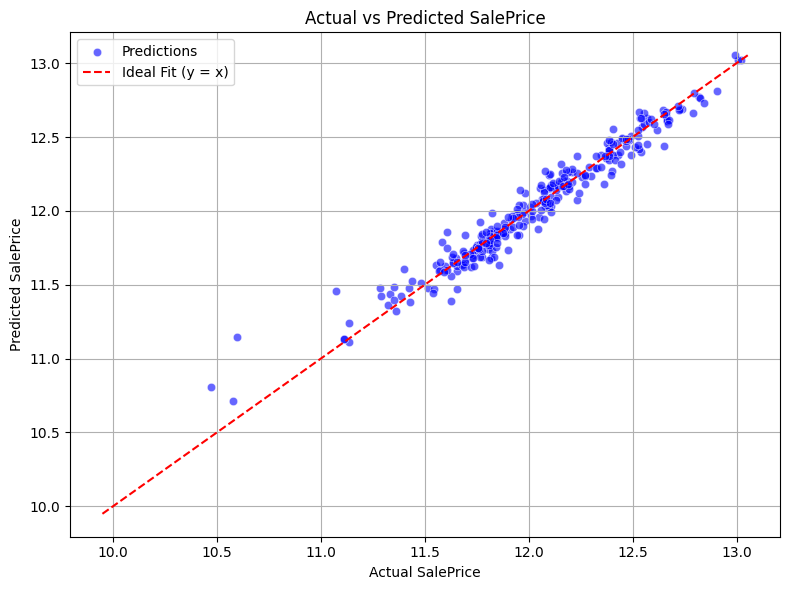

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
plot_actual_vs_pred(logy_test_true.values, logy_test_pred)

In [43]:
test_low_price = X_test.loc[logy_test_true < 11.25]
test_low_price.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

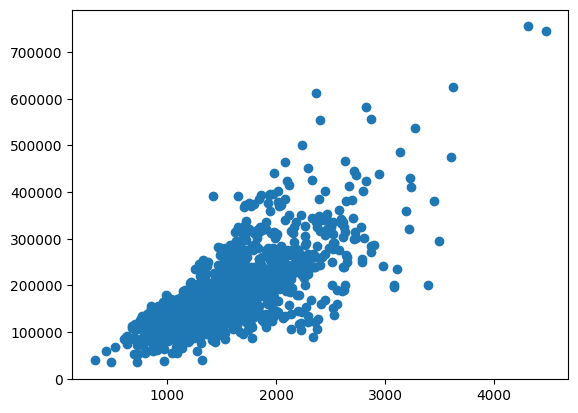

In [44]:
plt.scatter(train["GrLivArea"], np.expm1(train["SalePrice"]))
plt.show()